# 🏥 Medical Insurance Cost Prediction
### End-to-End Regression Project

---

**Domain:** Healthcare & Insurance  
**Goal:** Predict individual medical insurance charges based on demographic and health factors.  
**Tech Stack:** Python · Pandas · Scikit-learn · XGBoost · MLflow · Matplotlib · Seaborn

---

## 📋 Table of Contents
1. [Library Imports](#1)
2. [Load & Inspect Dataset](#2)
3. [Data Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Feature Engineering](#5)
6. [Model Training & Evaluation](#6)
7. [MLflow Experiment Tracking](#7)
8. [Best Model – Final Prediction](#8)

---
## 1. 📦 Library Imports <a id='1'></a>

In [1]:
# ── Core Libraries ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ── Preprocessing ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ── Models ──────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# ── Metrics ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── MLflow ──────────────────────────────────────────────────────────────────────
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models.signature import infer_signature

print('✅ All libraries imported successfully!')
print(f'   NumPy     : {np.__version__}')
print(f'   Pandas    : {pd.__version__}')
print(f'   MLflow    : {mlflow.__version__}')

✅ All libraries imported successfully!
   NumPy     : 2.1.3
   Pandas    : 2.3.3
   MLflow    : 3.9.0


---
## 2. 📂 Load & Inspect Dataset <a id='2'></a>

In [2]:
# Load dataset — update path if needed
df = pd.read_csv('medical_insurance.csv')

print('━' * 50)
print(f'  Dataset Shape  : {df.shape[0]} rows × {df.shape[1]} columns')
print('━' * 50)
df.head(10)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset Shape  : 2772 rows × 7 columns
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [4]:
# Statistical summary
df.describe().round(2)

,age,bmi,children,charges
count,2772.00,2772.00,2772.00,2772.00
mean,39.11,30.70,1.10,13261.37
std,14.08,6.13,1.21,12151.77
min,18.00,15.96,0.00,1121.87
25%,26.00,26.22,0.00,4687.80
50%,39.00,30.45,1.00,9333.01
75%,51.00,34.77,2.00,16577.78
max,64.00,53.13,5.00,63770.43


In [5]:
# Categorical column distributions
for col in ['sex', 'smoker', 'region']:
    print(f'\n🔹 {col.upper()} value counts:')
    print(df[col].value_counts())


🔹 SEX value counts:
sex
male      1406
female    1366
Name: count, dtype: int64

🔹 SMOKER value counts:
smoker
no     2208
yes     564
Name: count, dtype: int64

🔹 REGION value counts:
region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64


---
## 3. 🔧 Data Preprocessing <a id='3'></a>

In [6]:
# ── 3.1 Check Missing Values ────────────────────────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing: 0


In [7]:
# ── 3.2 Check Duplicates ────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

if dups > 0:
    df = df.drop_duplicates()
    print(f'  ✅ Removed duplicates. New shape: {df.shape}')
else:
    print('  ✅ No duplicates found.')

Duplicate rows: 1435
  ✅ Removed duplicates. New shape: (1337, 7)


In [8]:
# ── 3.3 Encode Categorical Variables ───────────────────────────────────────────
df_encoded = df.copy()

# Binary encoding
df_encoded['sex']    = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

# One-Hot Encoding for region
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

print('Encoded DataFrame columns:')
print(df_encoded.columns.tolist())
df_encoded.head()

Encoded DataFrame columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


---
## 4. 📊 Exploratory Data Analysis (EDA) <a id='4'></a>

### 4.1 Univariate Analysis

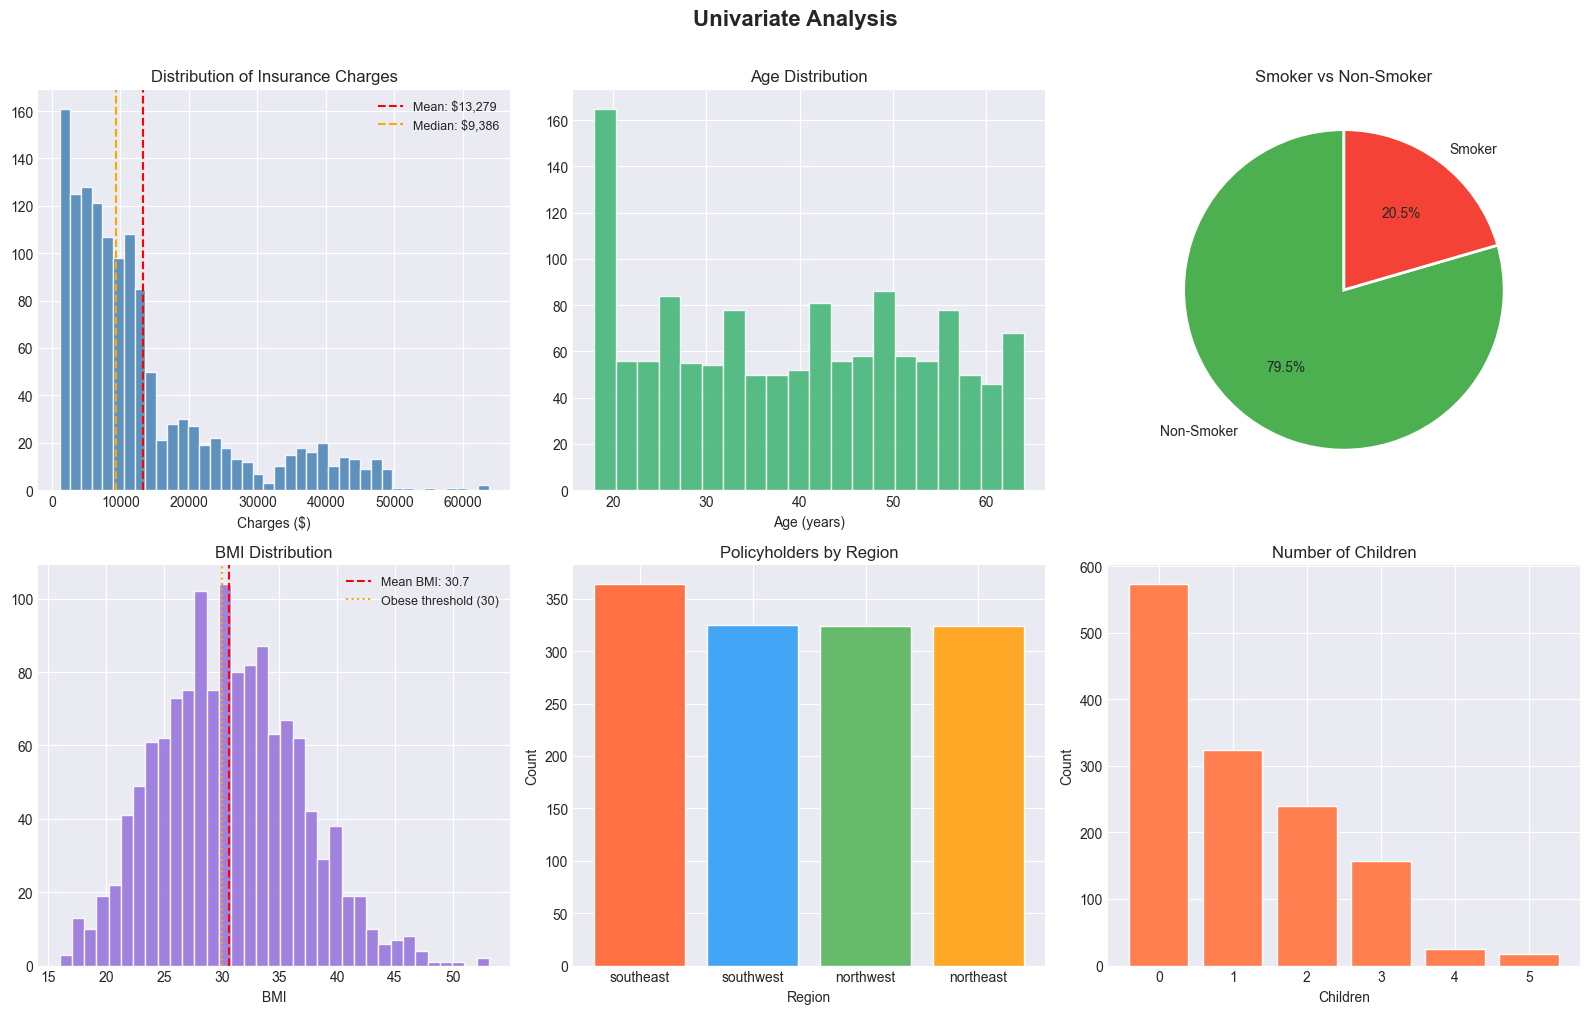

✅ Univariate plots saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold', y=1.01)

# 1. Distribution of Charges
axes[0,0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
axes[0,0].axvline(df['charges'].median(), color='orange', linestyle='--', label=f'Median: ${df["charges"].median():,.0f}')
axes[0,0].set_title('Distribution of Insurance Charges')
axes[0,0].set_xlabel('Charges ($)')
axes[0,0].legend(fontsize=9)

# 2. Age Distribution
axes[0,1].hist(df['age'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age (years)')

# 3. Smoker vs Non-Smoker
smoker_counts = df['smoker'].value_counts()
axes[0,2].pie(smoker_counts, labels=['Non-Smoker', 'Smoker'],
              autopct='%1.1f%%', colors=['#4CAF50','#F44336'],
              startangle=90, wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0,2].set_title('Smoker vs Non-Smoker')

# 4. BMI Distribution
axes[1,0].hist(df['bmi'], bins=35, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1,0].axvline(df['bmi'].mean(), color='red', linestyle='--', label=f'Mean BMI: {df["bmi"].mean():.1f}')
axes[1,0].axvline(30, color='orange', linestyle=':', label='Obese threshold (30)')
axes[1,0].set_title('BMI Distribution')
axes[1,0].set_xlabel('BMI')
axes[1,0].legend(fontsize=9)

# 5. Region Distribution
region_counts = df['region'].value_counts()
axes[1,1].bar(region_counts.index, region_counts.values, color=['#FF7043','#42A5F5','#66BB6A','#FFA726'], edgecolor='white')
axes[1,1].set_title('Policyholders by Region')
axes[1,1].set_xlabel('Region')
axes[1,1].set_ylabel('Count')

# 6. Children Distribution
children_counts = df['children'].value_counts().sort_index()
axes[1,2].bar(children_counts.index, children_counts.values, color='coral', edgecolor='white')
axes[1,2].set_title('Number of Children')
axes[1,2].set_xlabel('Children')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Univariate plots saved.')

### 4.2 Bivariate Analysis

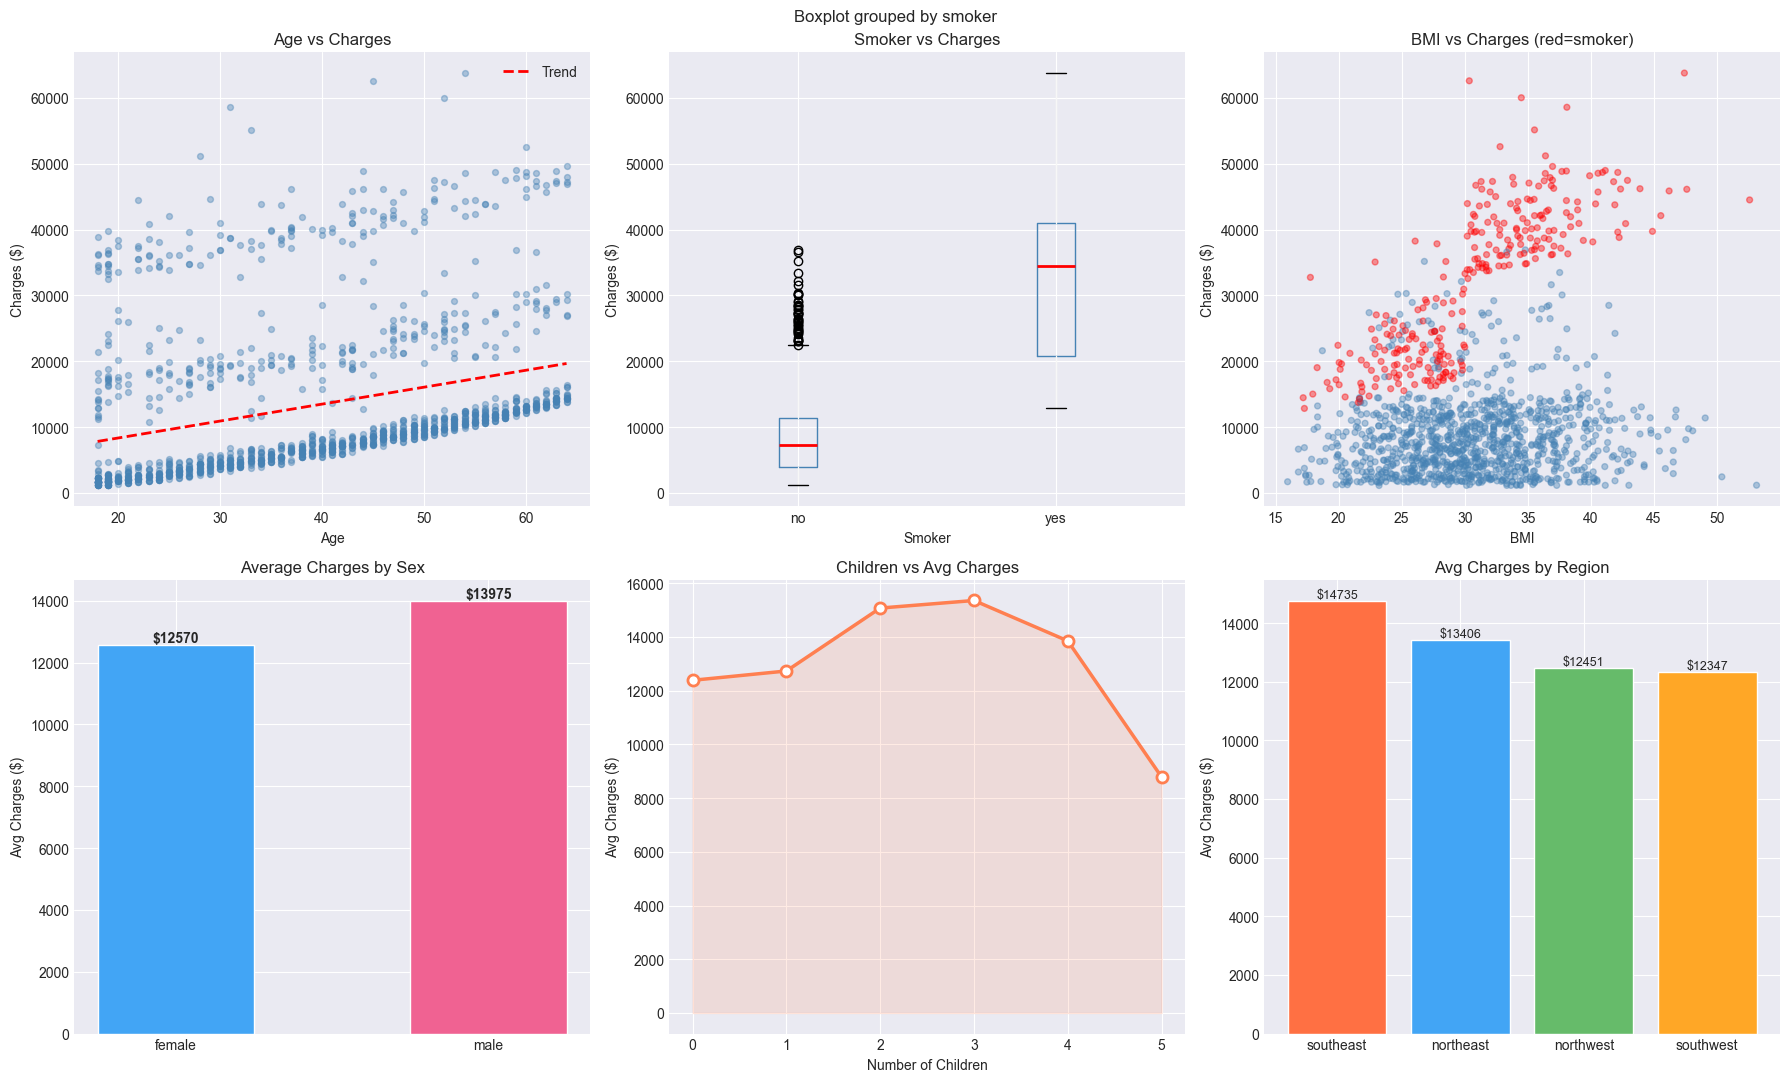

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Bivariate Analysis', fontsize=16, fontweight='bold')

# 1. Age vs Charges
axes[0,0].scatter(df['age'], df['charges'], alpha=0.4, color='steelblue', s=18)
z = np.polyfit(df['age'], df['charges'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0,0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[0,0].set_title('Age vs Charges')
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Charges ($)')
axes[0,0].legend()

# 2. Smoker vs Charges (Boxplot)
df.boxplot(column='charges', by='smoker', ax=axes[0,1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0,1].set_title('Smoker vs Charges')
axes[0,1].set_xlabel('Smoker'); axes[0,1].set_ylabel('Charges ($)')
plt.sca(axes[0,1]); plt.title('Smoker vs Charges')

# 3. BMI vs Charges
scatter_colors = df['smoker'].map({'yes': 'red', 'no': 'steelblue'})
axes[0,2].scatter(df['bmi'], df['charges'], c=scatter_colors, alpha=0.4, s=18)
axes[0,2].set_title('BMI vs Charges (red=smoker)')
axes[0,2].set_xlabel('BMI'); axes[0,2].set_ylabel('Charges ($)')

# 4. Sex vs Avg Charges
sex_avg = df.groupby('sex')['charges'].mean()
bars = axes[1,0].bar(sex_avg.index, sex_avg.values, color=['#42A5F5','#F06292'], edgecolor='white', width=0.5)
axes[1,0].bar_label(bars, fmt='$%.0f', fontsize=10, fontweight='bold')
axes[1,0].set_title('Average Charges by Sex')
axes[1,0].set_ylabel('Avg Charges ($)')

# 5. Children vs Avg Charges
children_avg = df.groupby('children')['charges'].mean()
axes[1,1].plot(children_avg.index, children_avg.values, marker='o', linewidth=2.5,
               color='coral', markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1,1].fill_between(children_avg.index, children_avg.values, alpha=0.15, color='coral')
axes[1,1].set_title('Children vs Avg Charges')
axes[1,1].set_xlabel('Number of Children'); axes[1,1].set_ylabel('Avg Charges ($)')

# 6. Region vs Avg Charges
region_avg = df.groupby('region')['charges'].mean().sort_values(ascending=False)
bars2 = axes[1,2].bar(region_avg.index, region_avg.values,
                       color=['#FF7043','#42A5F5','#66BB6A','#FFA726'], edgecolor='white')
axes[1,2].bar_label(bars2, fmt='$%.0f', fontsize=9)
axes[1,2].set_title('Avg Charges by Region')
axes[1,2].set_ylabel('Avg Charges ($)')

plt.tight_layout()
plt.savefig('eda_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Multivariate Analysis

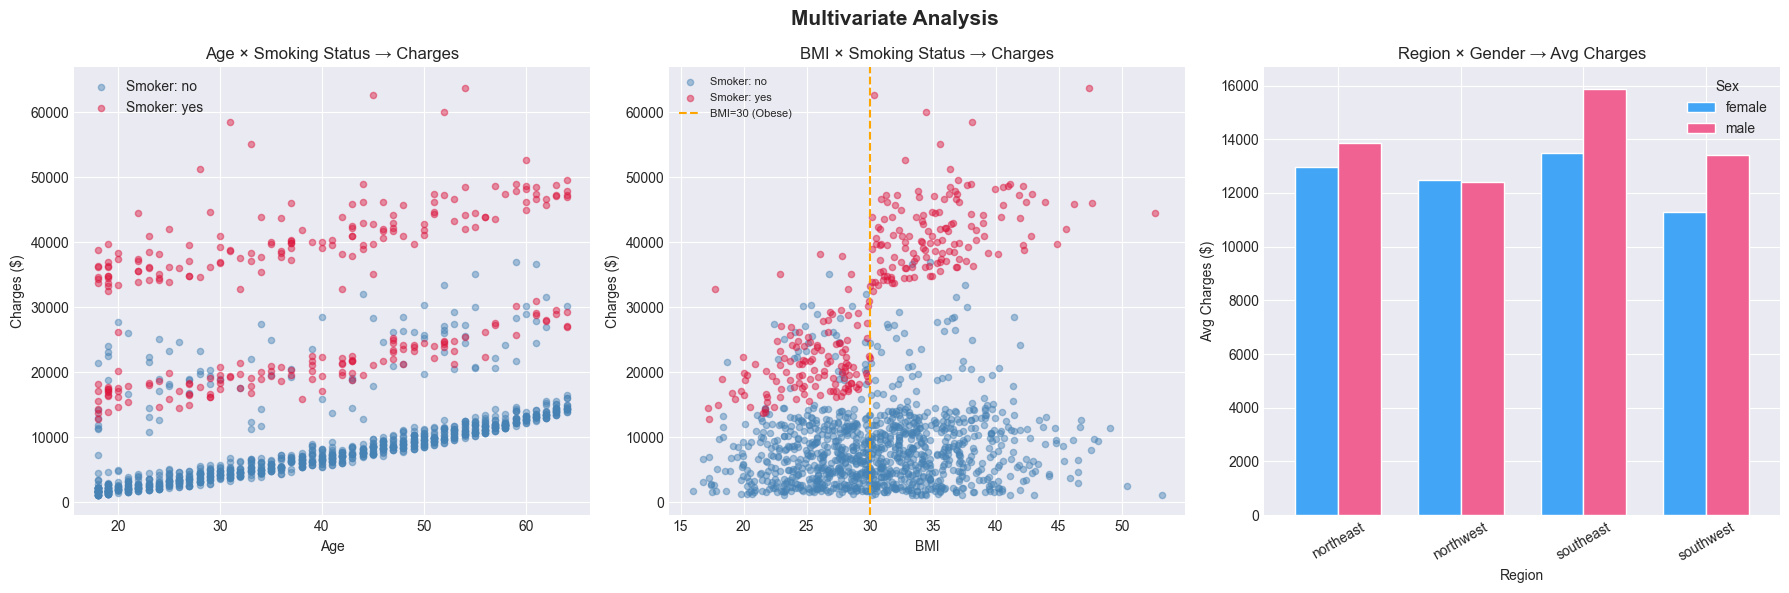

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Multivariate Analysis', fontsize=15, fontweight='bold')

# 1. Age × Smoking → Charges
for label, group in df.groupby('smoker'):
    axes[0].scatter(group['age'], group['charges'],
                    label=f'Smoker: {label}', alpha=0.45, s=20,
                    color='crimson' if label == 'yes' else 'steelblue')
axes[0].set_title('Age × Smoking Status → Charges')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Charges ($)')
axes[0].legend()

# 2. BMI × Smoking → Charges
for label, group in df.groupby('smoker'):
    axes[1].scatter(group['bmi'], group['charges'],
                    label=f'Smoker: {label}', alpha=0.45, s=20,
                    color='crimson' if label == 'yes' else 'steelblue')
axes[1].axvline(30, color='orange', linestyle='--', linewidth=1.5, label='BMI=30 (Obese)')
axes[1].set_title('BMI × Smoking Status → Charges')
axes[1].set_xlabel('BMI'); axes[1].set_ylabel('Charges ($)')
axes[1].legend(fontsize=8)

# 3. Gender × Region → Avg Charges (Grouped bar)
pivot = df.groupby(['region','sex'])['charges'].mean().unstack()
pivot.plot(kind='bar', ax=axes[2], color=['#42A5F5','#F06292'], edgecolor='white', width=0.7)
axes[2].set_title('Region × Gender → Avg Charges')
axes[2].set_xlabel('Region'); axes[2].set_ylabel('Avg Charges ($)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Sex')

plt.tight_layout()
plt.savefig('eda_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Correlation Analysis

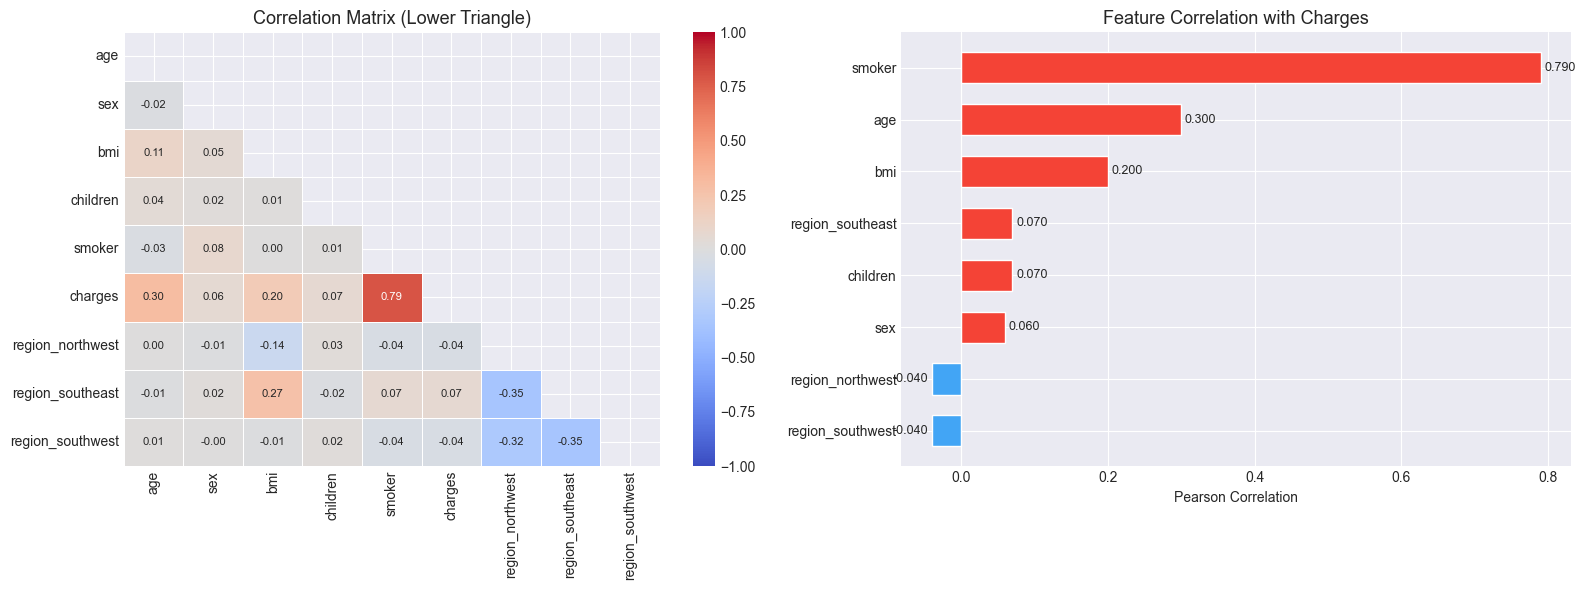


🔑 Top correlated features with charges:
smoker              0.79
age                 0.30
bmi                 0.20
children            0.07
region_southeast    0.07
sex                 0.06
region_southwest   -0.04
region_northwest   -0.04
Name: charges, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Correlation Heatmap
corr_matrix = df_encoded.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
axes[0].set_title('Correlation Matrix (Lower Triangle)', fontsize=13)

# 2. Feature Correlation with Charges
corr_with_charges = corr_matrix['charges'].drop('charges').sort_values(ascending=True)
colors = ['#F44336' if v > 0 else '#42A5F5' for v in corr_with_charges]
axes[1].barh(corr_with_charges.index, corr_with_charges.values, color=colors, edgecolor='white', height=0.6)
axes[1].axvline(0, color='white', linewidth=0.8)
axes[1].set_title('Feature Correlation with Charges', fontsize=13)
axes[1].set_xlabel('Pearson Correlation')
for i, v in enumerate(corr_with_charges.values):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔑 Top correlated features with charges:')
print(corr_with_charges.sort_values(ascending=False))

### 4.5 Outlier Detection

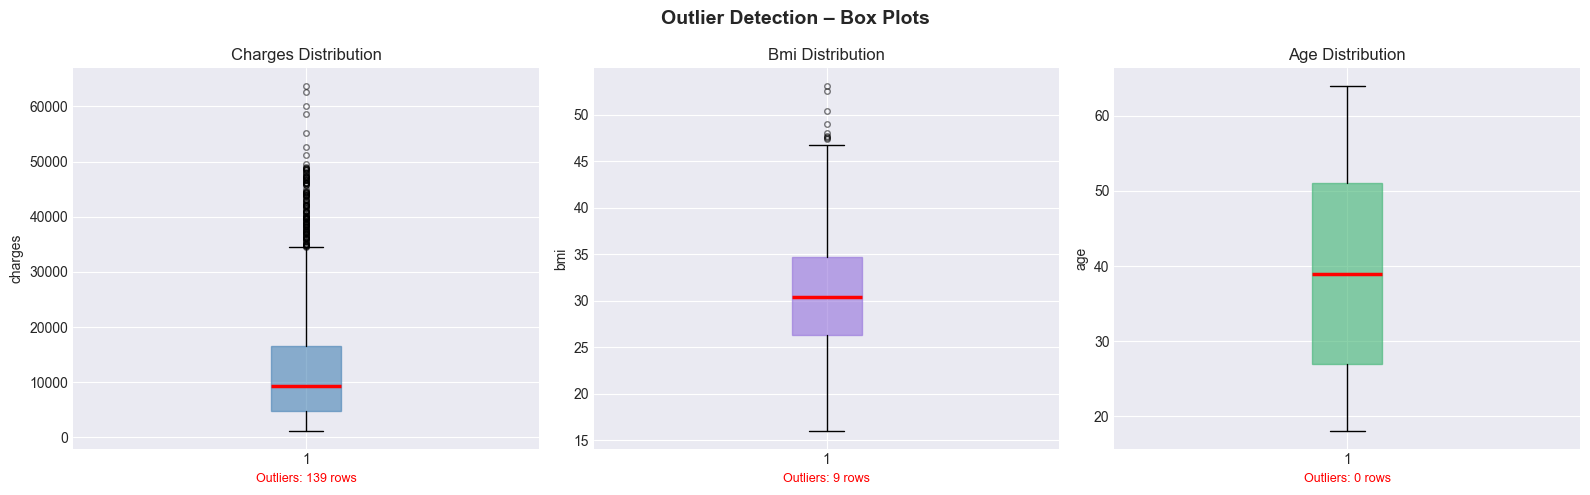


💰 Top 5 Highest Insurance Charges:


,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Outlier Detection – Box Plots', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, ['charges', 'bmi', 'age'], ['steelblue', 'mediumpurple', 'mediumseagreen']):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6, color=color),
               medianprops=dict(color='red', linewidth=2.5),
               flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5))
    ax.set_title(f'{col.capitalize()} Distribution')
    ax.set_ylabel(col)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    ax.set_xlabel(f'Outliers: {len(outliers)} rows', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top 5 most expensive records
print('\n💰 Top 5 Highest Insurance Charges:')
df.nlargest(5, 'charges')[['age','sex','bmi','children','smoker','region','charges']]

---
## 5. ⚙️ Feature Engineering <a id='5'></a>

In [14]:
df_fe = df_encoded.copy()

# 1. BMI Category (numerical)
def bmi_category(bmi):
    if bmi < 18.5: return 0   # Underweight
    elif bmi < 25: return 1   # Normal
    elif bmi < 30: return 2   # Overweight
    else:          return 3   # Obese

df_fe['bmi_category'] = df_fe['bmi'].apply(bmi_category)

# 2. Age Group
df_fe['age_group'] = pd.cut(df_fe['age'],
                             bins=[17, 25, 35, 45, 55, 65],
                             labels=[0, 1, 2, 3, 4]).astype(int)

# 3. Smoker × BMI Interaction (high-risk flag)
df_fe['smoker_bmi'] = df_fe['smoker'] * df_fe['bmi']

# 4. Smoker × Age Interaction
df_fe['smoker_age'] = df_fe['smoker'] * df_fe['age']

# 5. Obese Smoker flag
df_fe['obese_smoker'] = ((df_fe['bmi'] >= 30) & (df_fe['smoker'] == 1)).astype(int)

print('✅ Feature Engineering complete!')
print(f'   Original features  : {df_encoded.shape[1]}')
print(f'   Engineered features: {df_fe.shape[1]}')
print(f'   New features added : bmi_category, age_group, smoker_bmi, smoker_age, obese_smoker')
df_fe.head()

# Save cleaned & feature-engineered dataset
df_fe.to_csv('cleaned_medical_insurance.csv', index=False)
print('✅ Cleaned dataset saved as cleaned_medical_insurance.csv')

✅ Feature Engineering complete!
   Original features  : 9
   Engineered features: 14
   New features added : bmi_category, age_group, smoker_bmi, smoker_age, obese_smoker
✅ Cleaned dataset saved as cleaned_medical_insurance.csv


---
## 6. 🤖 Model Training & Evaluation <a id='6'></a>

In [15]:
# ── Train/Test Split ────────────────────────────────────────────────────────────
X = df_fe.drop('charges', axis=1)
y = df_fe['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (used for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test size  : {X_test.shape[0]} samples')
print(f'Features   : {X_train.shape[1]}')

Train size : 1069 samples
Test size  : 268 samples
Features   : 13


In [16]:
# ── Define 7 Models ─────────────────────────────────────────────────────────────
models = {
    'Linear Regression'        : LinearRegression(),
    'Ridge Regression'         : Ridge(alpha=1.0),
    'Lasso Regression'         : Lasso(alpha=0.5),
    'Decision Tree'            : DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest'            : RandomForestRegressor(n_estimators=200, max_depth=10,
                                                       random_state=42, n_jobs=-1),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                            max_depth=4, random_state=42),
    'XGBoost'                  : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                               max_depth=5, random_state=42,
                                               eval_metric='rmse', verbosity=0)
}

# ── Helper: Evaluate model ──────────────────────────────────────────────────────
def evaluate(model, X_tr, X_te, y_tr, y_te, use_scaled=False):
    Xtr = X_tr if not use_scaled else X_train_scaled
    Xte = X_te if not use_scaled else X_test_scaled
    model.fit(Xtr, y_tr)
    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    return {'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R2': round(r2,4)}, pred

print('✅ Models defined. Ready for training.')

✅ Models defined. Ready for training.


In [17]:
# ── Train & Evaluate All Models ─────────────────────────────────────────────────
linear_models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
results = {}
predictions = {}

for name, model in models.items():
    use_scaled = name in linear_models
    metrics, pred = evaluate(model, X_train, X_test, y_train, y_test, use_scaled=use_scaled)
    results[name] = metrics
    predictions[name] = pred
    print(f'  ✔ {name:<26} | RMSE: {metrics["RMSE"]:>10,.2f} | MAE: {metrics["MAE"]:>10,.2f} | R²: {metrics["R2"]:.4f}')

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print('\n📊 Model Comparison (sorted by R²):')
results_df

  ✔ Linear Regression          | RMSE:   4,048.56 | MAE:   2,268.52 | R²: 0.9108
  ✔ Ridge Regression           | RMSE:   4,050.34 | MAE:   2,265.41 | R²: 0.9107
  ✔ Lasso Regression           | RMSE:   4,048.74 | MAE:   2,267.97 | R²: 0.9108
  ✔ Decision Tree              | RMSE:   4,505.84 | MAE:   2,661.77 | R²: 0.8895
  ✔ Random Forest              | RMSE:   4,547.23 | MAE:   2,548.24 | R²: 0.8875
  ✔ Gradient Boosting          | RMSE:   4,355.15 | MAE:   2,487.98 | R²: 0.8968
  ✔ XGBoost                    | RMSE:   4,478.63 | MAE:   2,563.24 | R²: 0.8908

📊 Model Comparison (sorted by R²):


,RMSE,MAE,R2
Linear Regression,4048.56,2268.52,0.9108
Lasso Regression,4048.74,2267.97,0.9108
Ridge Regression,4050.34,2265.41,0.9107
Gradient Boosting,4355.15,2487.98,0.8968
XGBoost,4478.63,2563.24,0.8908
Decision Tree,4505.84,2661.77,0.8895
Random Forest,4547.23,2548.24,0.8875


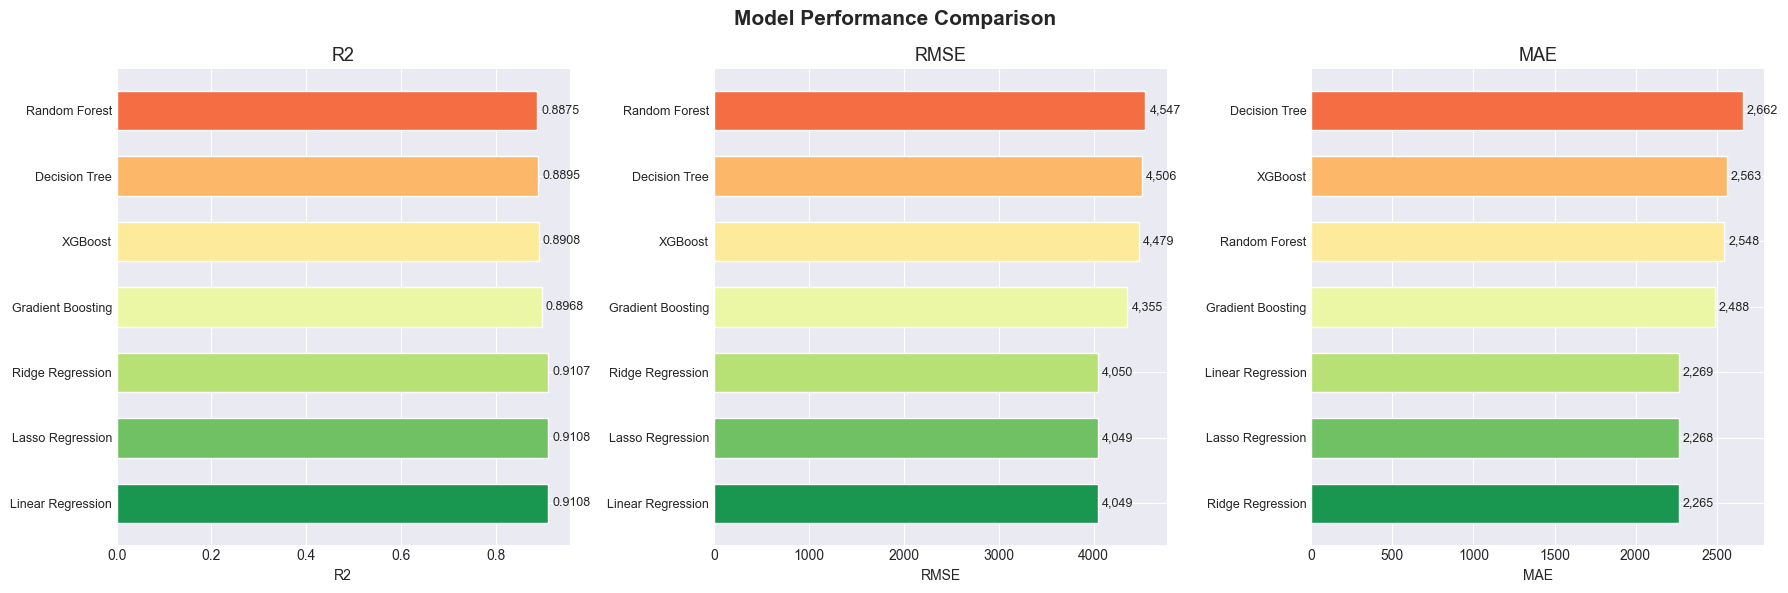

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results_df)))

for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    vals = results_df[metric].sort_values(ascending=(metric != 'R2'))
    bars = ax.barh(vals.index, vals.values, color=colors[::-1], edgecolor='white', height=0.6)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + (bar.get_width()*0.01), bar.get_y() + bar.get_height()/2,
                f'{val:,.4f}' if metric == 'R2' else f'{val:,.0f}',
                va='center', fontsize=9)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel(metric)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 Best Model : Linear Regression
   R²   : 0.9108
   RMSE : $4,048.56
   MAE  : $2,268.52


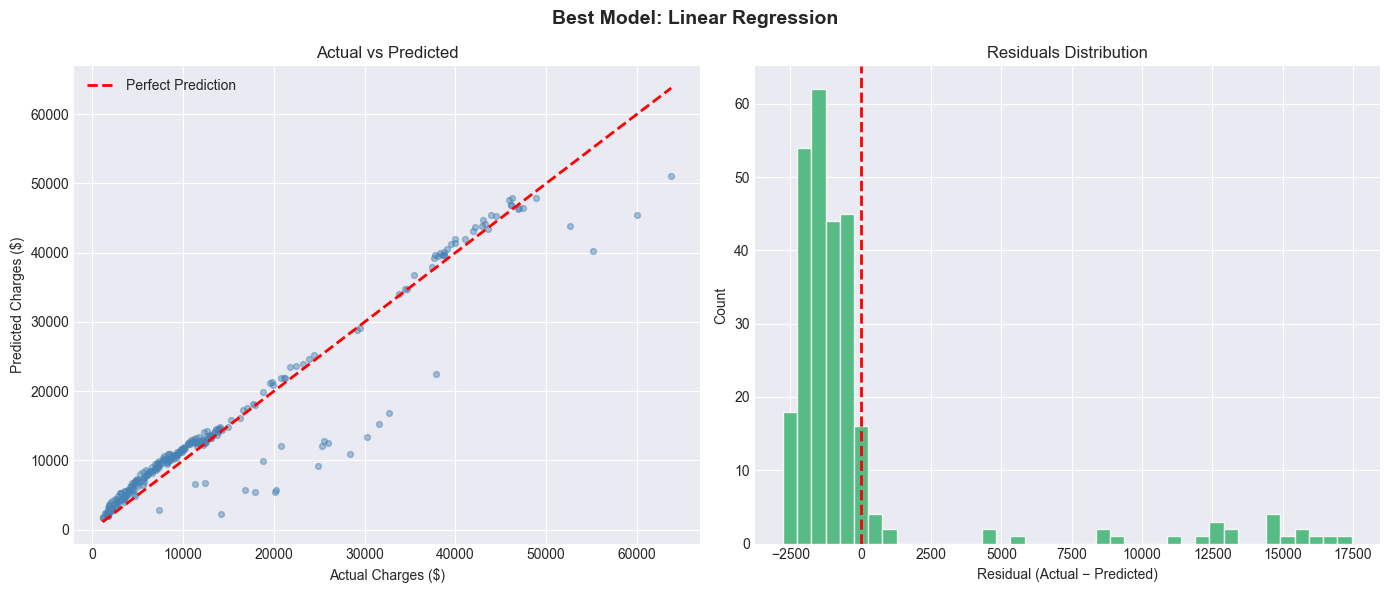

In [19]:
# ── Best Model Analysis ─────────────────────────────────────────────────────────
best_model_name = results_df['R2'].idxmax()
best_metrics    = results_df.loc[best_model_name]
best_preds      = predictions[best_model_name]

print(f'🏆 Best Model : {best_model_name}')
print(f'   R²   : {best_metrics["R2"]:.4f}')
print(f'   RMSE : ${best_metrics["RMSE"]:,.2f}')
print(f'   MAE  : ${best_metrics["MAE"]:,.2f}')

# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Best Model: {best_model_name}', fontsize=14, fontweight='bold')

axes[0].scatter(y_test, best_preds, alpha=0.45, color='steelblue', s=18)
min_val, max_val = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Charges ($)'); axes[0].set_ylabel('Predicted Charges ($)')
axes[0].legend()

residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Feature Importance (Tree-based models) ──────────────────────────────────────
best_model_obj = models[best_model_name]

if hasattr(best_model_obj, 'feature_importances_'):
    importances = pd.Series(
        best_model_obj.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    colors = ['#F44336' if v > importances.median() else '#42A5F5' for v in importances]
    importances.plot(kind='barh', color=colors, edgecolor='white')
    plt.title(f'Feature Importance – {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nTop 5 Most Important Features:')
    print(importances.sort_values(ascending=False).head())
else:
    print(f'Feature importance not available for {best_model_name}.')

Feature importance not available for Linear Regression.


---
## 7. 📈 MLflow Experiment Tracking <a id='7'></a>

In [21]:
# ── MLflow Setup ────────────────────────────────────────────────────────────────
mlflow.set_tracking_uri('mlruns')  # Local folder
experiment_name = 'Medical_Insurance_Cost_Prediction'
mlflow.set_experiment(experiment_name)

print(f'✅ MLflow tracking URI : mlruns/')
print(f'   Experiment name     : {experiment_name}')
print(f'   Run: mlflow ui  →  http://localhost:5000')

2026/03/26 23:18:42 INFO mlflow.tracking.fluent: Experiment with name 'Medical_Insurance_Cost_Prediction' does not exist. Creating a new experiment.


✅ MLflow tracking URI : mlruns/
   Experiment name     : Medical_Insurance_Cost_Prediction
   Run: mlflow ui  →  http://localhost:5000


In [22]:
# ── Log ALL Models to MLflow ────────────────────────────────────────────────────
run_ids = {}

for model_name, model in models.items():
    use_scaled = model_name in linear_models
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test

    with mlflow.start_run(run_name=model_name) as run:
        # Train
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds)

        # Log params
        mlflow.log_param('model_type', model_name)
        mlflow.log_param('test_size', 0.2)
        mlflow.log_param('n_features', X_train.shape[1])
        mlflow.log_param('n_train_samples', X_train.shape[0])
        if hasattr(model, 'get_params'):
            for k, v in model.get_params().items():
                try:
                    mlflow.log_param(k, v)
                except Exception:
                    pass

        # Log metrics
        mlflow.log_metric('RMSE', rmse)
        mlflow.log_metric('MAE', mae)
        mlflow.log_metric('R2', r2)

        # Log model artifact
        signature = infer_signature(X_test, preds)
        if model_name == 'XGBoost':
            mlflow.xgboost.log_model(model, artifact_path='model', signature=signature)
        else:
            mlflow.sklearn.log_model(model, artifact_path='model', signature=signature)

        run_ids[model_name] = run.info.run_id
        print(f'  ✔ Logged: {model_name:<26} | R²: {r2:.4f} | run_id: {run.info.run_id[:8]}...')

print('\n✅ All models logged to MLflow!')

2026/03/26 23:18:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 23:18:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✔ Logged: Linear Regression          | R²: 0.9108 | run_id: 91ceaf69...


2026/03/26 23:18:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✔ Logged: Ridge Regression           | R²: 0.9107 | run_id: 9e7c9eec...


2026/03/26 23:18:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

  ✔ Logged: Random Forest              | R²: 0.8875 | run_id: 66013436...


2026/03/26 23:19:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✔ Logged: Gradient Boosting          | R²: 0.8968 | run_id: 9bc56fe6...


2026/03/26 23:19:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✔ Logged: XGBoost                    | R²: 0.8908 | run_id: a20e135c...

✅ All models logged to MLflow!


In [23]:
# ── Register Best Model in MLflow Model Registry ────────────────────────────────
best_run_id    = run_ids[best_model_name]
model_uri      = f'runs:/{best_run_id}/model'
registered_name = 'MedicalInsuranceCostPredictor'

result = mlflow.register_model(model_uri=model_uri, name=registered_name)

print(f'✅ Model Registered Successfully!')
print(f'   Model Name    : {registered_name}')
print(f'   Best Model    : {best_model_name}')
print(f'   Run ID        : {best_run_id[:12]}...')
print(f'   Version       : {result.version}')
print(f'   Status        : {result.status}')

Successfully registered model 'MedicalInsuranceCostPredictor'.
2026/03/26 23:19:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 91ceaf692cb0451093dbf748fd359966 has no artifacts at artifact path 'model', registering model based on models:/m-3597a5d9c3e14ff6b95488e7cb72c480 instead


✅ Model Registered Successfully!
   Model Name    : MedicalInsuranceCostPredictor
   Best Model    : Linear Regression
   Run ID        : 91ceaf692cb0...
   Version       : 1
   Status        : READY


Created version '1' of model 'MedicalInsuranceCostPredictor'.


In [24]:
# ── Compare All MLflow Runs ─────────────────────────────────────────────────────
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name(experiment_name)
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.R2 DESC']
)

run_data = []
for r in runs:
    run_data.append({
        'Model'     : r.data.params.get('model_type', 'N/A'),
        'R2'        : round(r.data.metrics.get('R2', 0), 4),
        'RMSE'      : round(r.data.metrics.get('RMSE', 0), 2),
        'MAE'       : round(r.data.metrics.get('MAE', 0), 2),
        'Run ID'    : r.info.run_id[:10] + '...'
    })

mlflow_df = pd.DataFrame(run_data)
print('📊 MLflow Experiment Summary:')
mlflow_df

📊 MLflow Experiment Summary:


,Model,R2,RMSE,MAE,Run ID
0,Linear Regression,0.9108,4048.56,2268.52,91ceaf692c...
1,Lasso Regression,0.9108,4048.74,2267.97,54ea067e7b...
2,Ridge Regression,0.9107,4050.34,2265.41,9e7c9eec35...
3,Gradient Boosting,0.8968,4355.15,2487.98,9bc56fe675...
4,XGBoost,0.8908,4478.63,2563.24,a20e135c35...
5,Decision Tree,0.8895,4505.84,2661.77,dc5e739b5a...
6,Random Forest,0.8875,4547.23,2548.24,6601343604...


---
## 8. 🎯 Best Model – Final Prediction <a id='8'></a>

In [25]:
# ── Load Best Model — DIRECT OBJECT (MLflow wrapper bypass) ──────────────────
best_model_obj = models[best_model_name]  # ✅ direct sklearn model
print(f'✅ Using model: {best_model_name} (direct object)')

# ── Sample Predictions ────────────────────────────────────────────────────────
sample_data   = X_test.head(10)
sample_actual = y_test.head(10).values

# Linear model needs scaled data
sample_scaled = scaler.transform(sample_data)
sample_preds  = best_model_obj.predict(sample_scaled)

comparison_df = pd.DataFrame({
    'Actual Charges'   : [f'${v:,.2f}' for v in sample_actual],
    'Predicted Charges': [f'${v:,.2f}' for v in sample_preds],
    'Error ($)'        : [f'${abs(a-p):,.2f}' for a, p in zip(sample_actual, sample_preds)]
})
print('\n🔍 Sample Predictions (first 10 test records):')
comparison_df

✅ Using model: Linear Regression (direct object)

🔍 Sample Predictions (first 10 test records):


,Actual Charges,Predicted Charges,Error ($)
0,"$8,688.86","$10,306.03","$1,617.17"
1,"$5,708.87","$6,943.84","$1,234.98"
2,"$11,436.74","$13,231.34","$1,794.60"
3,"$38,746.36","$40,073.08","$1,326.73"
4,"$4,463.21","$6,492.00","$2,028.79"
5,"$9,304.70","$10,977.88","$1,673.18"
6,"$38,511.63","$39,691.02","$1,179.39"
7,"$2,150.47","$3,013.50",$863.03
8,"$7,345.73","$9,864.34","$2,518.61"
9,"$10,264.44","$11,847.06","$1,582.62"


In [26]:
# ── Custom Input Prediction ─────────────────────────────────────────────────────
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    sex_enc    = 1 if sex == 'male' else 0
    smoker_enc = 1 if smoker == 'yes' else 0

    input_dict = {
        'age'              : age,
        'sex'              : sex_enc,
        'bmi'              : float(bmi),
        'children'         : children,
        'smoker'           : smoker_enc,
        'region_northwest' : region == 'northwest',  # bool directly
        'region_southeast' : region == 'southeast',
        'region_southwest' : region == 'southwest',
        'bmi_category'     : 0 if bmi < 18.5 else (1 if bmi < 25 else (2 if bmi < 30 else 3)),
        'age_group'        : 0 if age <= 25 else (1 if age <= 35 else (2 if age <= 45 else (3 if age <= 55 else 4))),
        'smoker_bmi'       : smoker_enc * float(bmi),
        'smoker_age'       : smoker_enc * age,
        'obese_smoker'     : int(bmi >= 30 and smoker == 'yes')
    }

    input_df     = pd.DataFrame([input_dict])[X.columns]
    input_scaled = scaler.transform(input_df)           # ✅ scale karo
    return best_model_obj.predict(input_scaled)[0]      # ✅ direct model

# ── Example Predictions ───────────────────────────────────────────────────────
examples = [
    (25, 'male',   22.0, 0, 'no',  'northwest', 'Young healthy male'),
    (45, 'female', 32.5, 2, 'no',  'southeast', 'Middle-aged obese female'),
    (38, 'male',   29.0, 1, 'yes', 'northeast', 'Smoker, slightly overweight'),
    (55, 'female', 38.0, 3, 'yes', 'southwest', 'Obese smoker with 3 children'),
]

print('🎯 Custom Insurance Cost Predictions:')
print('='*70)
for age, sex, bmi, children, smoker, region, desc in examples:
    cost = predict_insurance_cost(age, sex, bmi, children, smoker, region)
    bmi_label = ('Underweight' if bmi < 18.5 else
                 'Normal'      if bmi < 25   else
                 'Overweight'  if bmi < 30   else 'Obese')
    print(f'  👤 {desc}')
    print(f'     Age: {age} | Sex: {sex} | BMI: {bmi} ({bmi_label}) | Smoker: {smoker}')
    print(f'     💰 Estimated Annual Cost: ${cost:,.2f}  (${cost/12:,.2f}/month)')
    print()

🎯 Custom Insurance Cost Predictions:
  👤 Young healthy male
     Age: 25 | Sex: male | BMI: 22.0 (Normal) | Smoker: no
     💰 Estimated Annual Cost: $4,443.78  ($370.31/month)

  👤 Middle-aged obese female
     Age: 45 | Sex: female | BMI: 32.5 (Obese) | Smoker: no
     💰 Estimated Annual Cost: $11,197.57  ($933.13/month)

  👤 Smoker, slightly overweight
     Age: 38 | Sex: male | BMI: 29.0 (Overweight) | Smoker: yes
     💰 Estimated Annual Cost: $23,025.45  ($1,918.79/month)

  👤 Obese smoker with 3 children
     Age: 55 | Sex: female | BMI: 38.0 (Obese) | Smoker: yes
     💰 Estimated Annual Cost: $47,921.72  ($3,993.48/month)



In [27]:
# ── Final Project Summary ────────────────────────────────────────────────────────
print('=' * 60)
print('  📋 MEDICAL INSURANCE COST PREDICTION – PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset         : {df.shape[0]} records, {df.shape[1]} features')
print(f'  Target Variable : charges (annual insurance cost)')
print(f'  Models Trained  : {len(models)}')
print(f'  Best Model      : {best_model_name}')
print(f'  Best R²         : {results[best_model_name]["R2"]:.4f}')
print(f'  Best RMSE       : ${results[best_model_name]["RMSE"]:,.2f}')
print(f'  Best MAE        : ${results[best_model_name]["MAE"]:,.2f}')
print(f'  MLflow Runs     : {len(run_ids)} experiments tracked')
print(f'  Registered As   : {registered_name} v{result.version}')
print('=' * 60)
print('  ✅ Project Complete!')
print('  🚀 Next step: Streamlit App (app.py)')

  📋 MEDICAL INSURANCE COST PREDICTION – PROJECT SUMMARY
  Dataset         : 1337 records, 7 features
  Target Variable : charges (annual insurance cost)
  Models Trained  : 7
  Best Model      : Linear Regression
  Best R²         : 0.9108
  Best RMSE       : $4,048.56
  Best MAE        : $2,268.52
  MLflow Runs     : 7 experiments tracked
  Registered As   : MedicalInsuranceCostPredictor v1
  ✅ Project Complete!
  🚀 Next step: Streamlit App (app.py)
